# Dissertation plots

Figures are ordered as: classical codes, topological codes, MKMN codes, bivariate-bicycle codes, and asymmetric codes. Captions are printed in notebook output and are not embedded in the saved images; multi-panel images use panel letters only.


In [17]:
from pathlib import Path
from math import comb
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import ndtr

plt.rcParams.update({
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 16,
})

PROJECT_DIRECTORY = Path.cwd()
DATA_DIRECTORY = PROJECT_DIRECTORY / 'Data'

def data_path(path):
    """Resolve an input file from either the project root or Data directory."""
    path = Path(path)
    if path.is_absolute() or path.exists():
        return path
    data_candidate = DATA_DIRECTORY / path
    return data_candidate if data_candidate.exists() else path

def data_glob(pattern):
    """Return matching input files from both supported data locations."""
    matches = list(PROJECT_DIRECTORY.glob(pattern))
    if DATA_DIRECTORY.exists():
        matches.extend(DATA_DIRECTORY.glob(pattern))
    return sorted(set(matches))

DISTANCES = (3, 5, 7, 9, 11)
SQRT_PI = np.sqrt(np.pi)
BLUE_GREEN_CMAP = plt.cm.viridis

def blue_green_colours(values, low=0.10, high=0.90):
    return dict(zip(values, BLUE_GREEN_CMAP(np.linspace(low, high, len(values)))))

def print_caption(text):
    print(f"Figure caption: {text}")

# Keep the PNG previews and also create an editable vector copy of every plot.
_matplotlib_savefig = plt.Figure.savefig
def savefig_with_svg(self, filename, *args, **kwargs):
    result = _matplotlib_savefig(self, filename, *args, **kwargs)
    path = Path(filename)
    if path.suffix.lower() != '.svg':
        svg_kwargs = {key: value for key, value in kwargs.items() if key != 'dpi'}
        _matplotlib_savefig(self, path.with_suffix('.svg'), *args, **svg_kwargs)
    return result
plt.Figure.savefig = savefig_with_svg

def gkp_physical_error_rate(sigmas, number_of_intervals=100):
    sigmas = np.asarray(sigmas, dtype=float)
    probability = np.zeros_like(sigmas)
    for m in range(number_of_intervals):
        lower = (2 * m + 0.5) * SQRT_PI / sigmas
        upper = (2 * m + 1.5) * SQRT_PI / sigmas
        probability += 2 * (ndtr(-lower) - ndtr(-upper))
    return probability

def load_curve(path, distance):
    path = data_path(path)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
    with path.open(encoding='utf-8') as file:
        distance_data = json.load(file)[str(distance)]

    if isinstance(distance_data, dict) and isinstance(distance_data.get('sigma'), list):
        sigma = np.asarray(distance_data['sigma'], dtype=float)
        rate = np.asarray(distance_data['rate'], dtype=float)
        error = np.asarray(distance_data['error_bar'], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        points = sorted(distance_data.values(), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        rate = np.asarray([point['rate'] for point in points], dtype=float)
        error = np.asarray([point['error_bar'] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])

    order = np.argsort(sigma)
    return sigma[order], physical[order], rate[order], error[order]

def closest_connected_point(curves):
    """Return the sampled x value where all connected curves are closest."""
    sampled = []
    for physical, rate in curves:
        sampled.append({round(float(x), 12): float(y)
                        for x, y in zip(physical, rate) if x > 0 and y > 0})
    common_x = sorted(set.intersection(*(set(curve) for curve in sampled)))
    if not common_x:
        raise ValueError('Curves have no common positive sampled points')
    return min(common_x, key=lambda x: np.std(np.log([curve[x] for curve in sampled])))

def load_block_curve(path):
    path = data_path(path)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
    with path.open(encoding='utf-8') as file:
        code_data = next(iter(json.load(file).values()))

    if isinstance(code_data.get('sigma'), list):
        sigma = np.asarray(code_data['sigma'], dtype=float)
        rate_key = 'block_rate' if 'block_rate' in code_data else 'rate'
        error_key = 'block_error_bar' if 'block_error_bar' in code_data else 'error_bar'
        rate = np.asarray(code_data[rate_key], dtype=float)
        error = np.asarray(code_data[error_key], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        points = sorted(code_data.values(), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        rate_key = 'block_rate' if 'block_rate' in points[0] else 'rate'
        error_key = 'block_error_bar' if 'block_error_bar' in points[0] else 'error_bar'
        rate = np.asarray([point[rate_key] for point in points], dtype=float)
        error = np.asarray([point[error_key] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])

    order = np.argsort(sigma)
    return sigma[order], physical[order], rate[order], error[order]

def prefer_existing(preferred, fallback):
    preferred_path = data_path(preferred)
    return preferred_path if preferred_path.exists() else data_path(fallback)


## Classical codes

Exact majority-vote logical error probabilities for distances 3, 5, 7, 9, and 11. The linear-scale plot is shown first, followed by the log-scale plot.


Figure caption: Logical bit-error probability of odd-distance classical repetition codes under independent bit flips, shown on a linear scale. The dashed line marks the majority-vote threshold p=0.5.


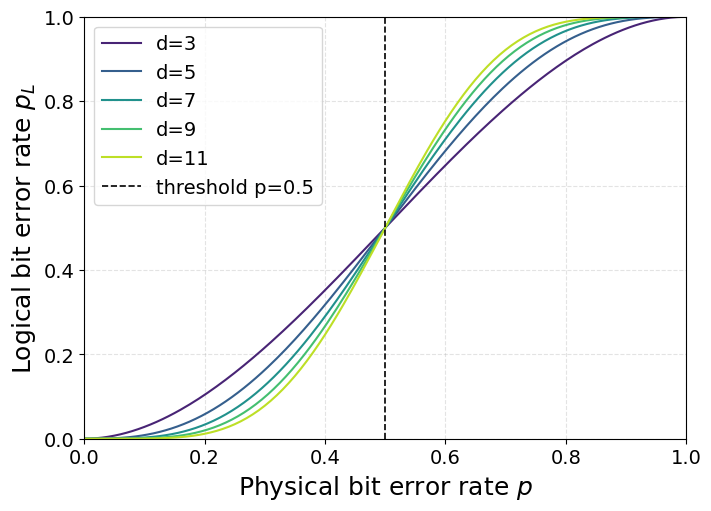

Figure caption: Logical bit-error probability of the same repetition codes on a logarithmic scale, emphasizing below-threshold suppression with increasing distance.


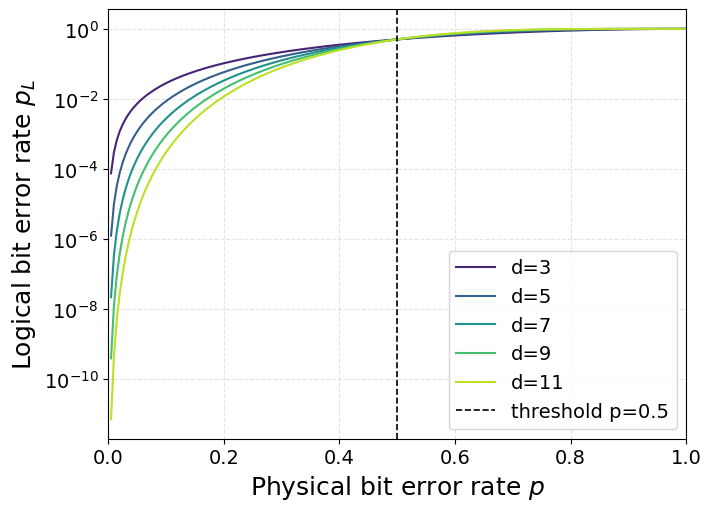

In [18]:
CLASSICAL_DISTANCES = (3, 5, 7, 9, 11)
classical_p = np.linspace(0.0, 1.0, 201)

def repetition_logical_error_rate(distance, physical_error_rate):
    p = np.asarray(physical_error_rate, dtype=float)
    return sum(
        comb(distance, weight) * p**weight * (1.0 - p)**(distance - weight)
        for weight in range(distance // 2 + 1, distance + 1)
    )

classical_rates = {distance: repetition_logical_error_rate(distance, classical_p)
                   for distance in CLASSICAL_DISTANCES}
classical_colors = blue_green_colours(CLASSICAL_DISTANCES)

print_caption('Logical bit-error probability of odd-distance classical repetition codes under independent bit flips, shown on a linear scale. The dashed line marks the majority-vote threshold p=0.5.')
fig, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
for distance, rate in classical_rates.items():
    axis.plot(classical_p, rate, color=classical_colors[distance], label=f'd={distance}')
axis.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='threshold p=0.5')
axis.set(xlabel=r'Physical bit error rate $p$', ylabel='Logical bit error rate $p_L$',
         xlim=(0, 1), ylim=(0, 1))
axis.grid(True, linestyle='--', alpha=0.35)
axis.legend(fontsize=14)
fig.savefig('classical_repetition_linear.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption('Logical bit-error probability of the same repetition codes on a logarithmic scale, emphasizing below-threshold suppression with increasing distance.')
fig, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
for distance, rate in classical_rates.items():
    visible = rate > 0
    axis.plot(classical_p[visible], rate[visible], color=classical_colors[distance], label=f'd={distance}')
axis.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='threshold p=0.5')
axis.set_yscale('log')
axis.set(xlabel=r'Physical bit error rate $p$', ylabel='Logical bit error rate $p_L$', xlim=(0, 1))
axis.grid(True, which='both', linestyle='--', alpha=0.35)
axis.legend(fontsize=14)
fig.savefig('classical_repetition_log.png', dpi=300, bbox_inches='tight')
plt.show()


### Physical GKP error probability versus Gaussian shift noise

Conversion between the Gaussian displacement standard deviation $\sigma$ and the physical GKP error probability.

Figure caption: Physical GKP error probability as a function of the Gaussian shift-noise standard deviation $\sigma$.


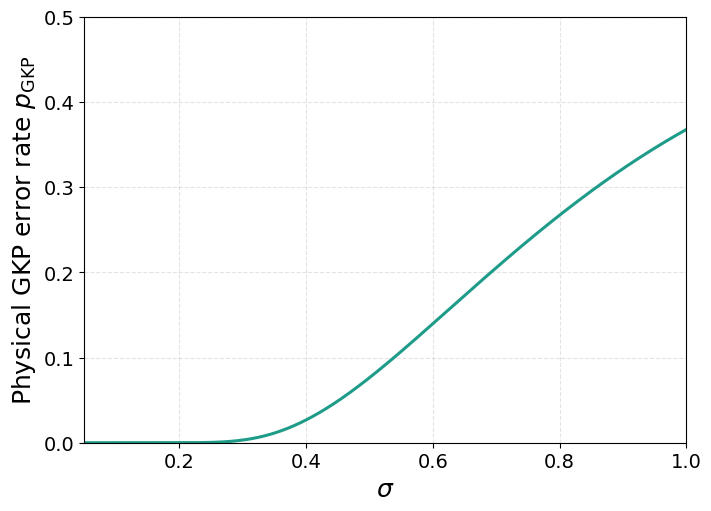

In [19]:
# Editable style and range settings
sigma_min = 0.05
sigma_max = 1.00
number_of_points = 500
figure_size = (7, 5)
line_colour = BLUE_GREEN_CMAP(0.55)
line_width = 2.2
label_fontsize = 18
tick_fontsize = 14
grid_alpha = 0.35
output_filename = 'diss_gkp_sigma_to_probability_d3.png'

sigma_values = np.linspace(sigma_min, sigma_max, number_of_points)
physical_gkp_error = gkp_physical_error_rate(sigma_values)

print_caption(r'Physical GKP error probability as a function of the Gaussian shift-noise standard deviation $\sigma$.')
fig, axis = plt.subplots(figsize=figure_size, constrained_layout=True)
axis.plot(sigma_values, physical_gkp_error, color=line_colour, linewidth=line_width)
axis.set_xlabel(r'$\sigma$', fontsize=label_fontsize)
axis.set_ylabel(r'Physical GKP error rate $p_{\mathrm{GKP}}$', fontsize=label_fontsize)
axis.tick_params(axis='both', labelsize=tick_fontsize)
axis.set_xlim(sigma_min, sigma_max)
axis.set_ylim(0, 0.5)
axis.grid(True, linestyle='--', alpha=grid_alpha)
fig.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

### Planar surface code: odd and even distances

Odd distances are compared together; the even-distance $d=4$ result is shown separately because it belongs to a different code family sequence.

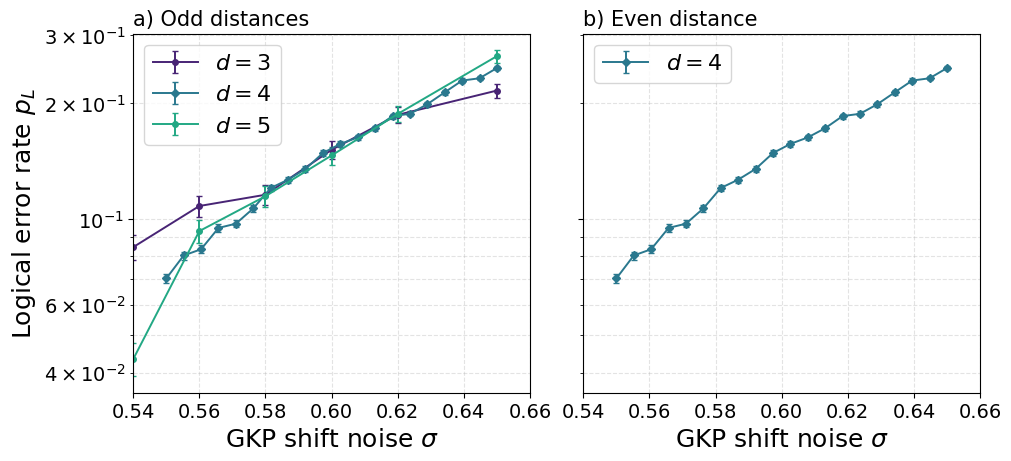

In [20]:
# Uses the refined d=4 cluster result automatically after it is downloaded.
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_surface_curve(distance):
    path = data_path(f'gkp_surface_2d_d{distance}_results.json')
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
    saved = next(iter(json.loads(path.read_text(encoding='utf-8')).values()))
    points = sorted(saved.values(), key=lambda point: point['sigma'])
    sigma = np.asarray([point['sigma'] for point in points], dtype=float)
    rate = np.asarray([point.get('block_rate', point.get('rate')) for point in points], dtype=float)
    error = np.asarray([point.get('block_error_bar', point.get('error_bar')) for point in points], dtype=float)
    return sigma, rate, error

surface_colours = {3: '#482475', 4: '#2a788e', 5: '#22a884'}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True, constrained_layout=True)
surface_panels = ((axes[0], (3, 4, 5), 'a) Odd distances'), (axes[1], (4,), 'b) Even distance'))

for axis, distances, title in surface_panels:
    for distance in distances:
        sigma, rate, error = load_surface_curve(distance)
        visible = (sigma >= 0.54) & (sigma <= 0.66) & (rate > 0)
        axis.errorbar(sigma[visible], rate[visible], yerr=error[visible],
                      color=surface_colours[distance], marker='D' if distance == 4 else 'o',
                      markersize=4, linewidth=1.4, capsize=2.5, label=fr'$d={distance}$')
    axis.set_title(title, loc='left')
    axis.set_xlabel(r'GKP shift noise $\sigma$')
    axis.set_xlim(0.54, 0.66)
    axis.set_yscale('log')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(frameon=True)

axes[0].set_ylabel('Logical error rate $p_L$')
fig.savefig('diss_surface_odd_even_separate.png', dpi=300, bbox_inches='tight')
plt.show()


## Topological codes


## Below-threshold exponential suppression

These figures use the dedicated suppression datasets. Standard and soft-GKP decoding are shown in separate panels using the same distance colours.


Figure caption: Planar Surface code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


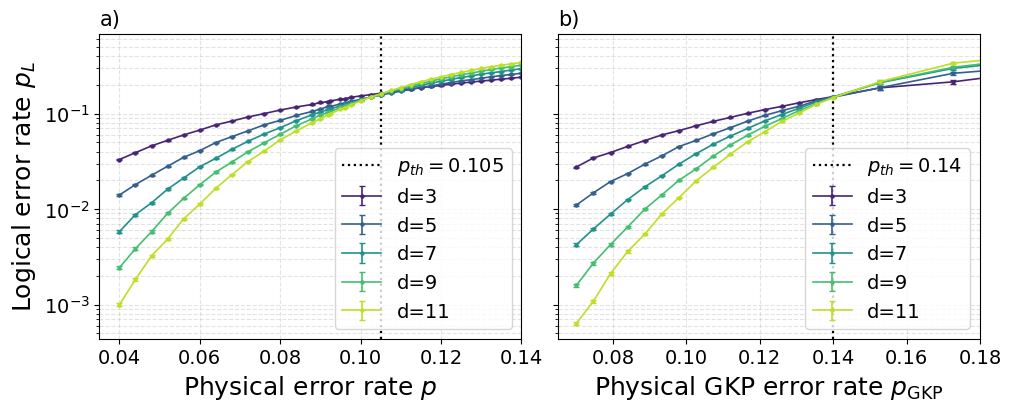

Figure caption: Planar surface code logical error rates under explicit hard-GKP sampling. Viridis colour denotes code distance.


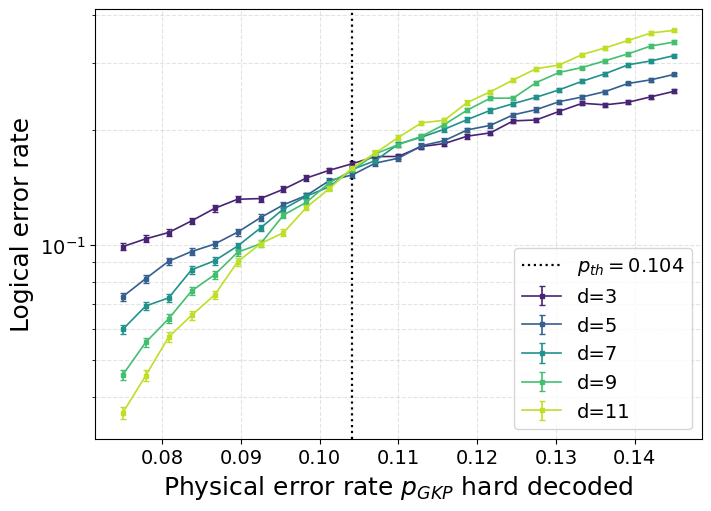

Figure caption: 2D Toric code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


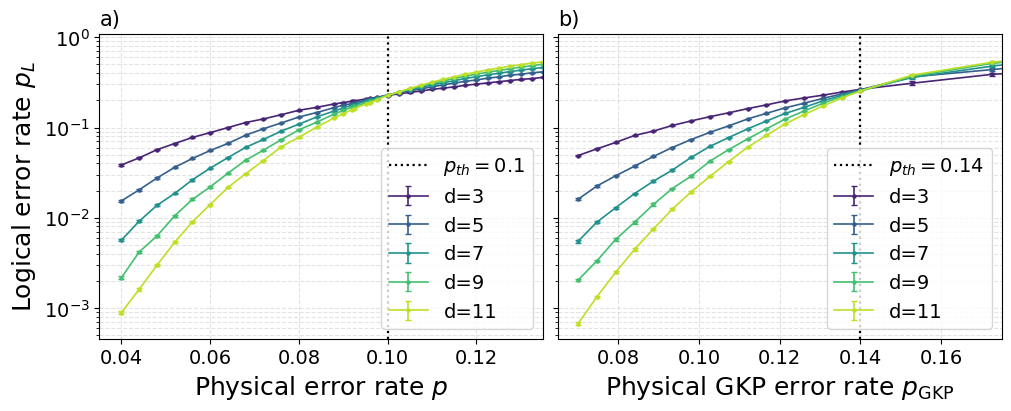

Figure caption: 2D toric code logical error rates under explicit hard-GKP sampling. Viridis colour denotes code distance.


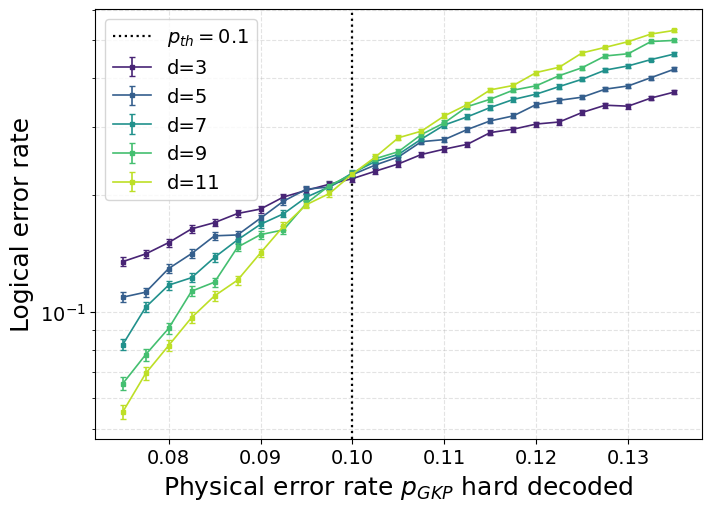

Figure caption: 3D Toric code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


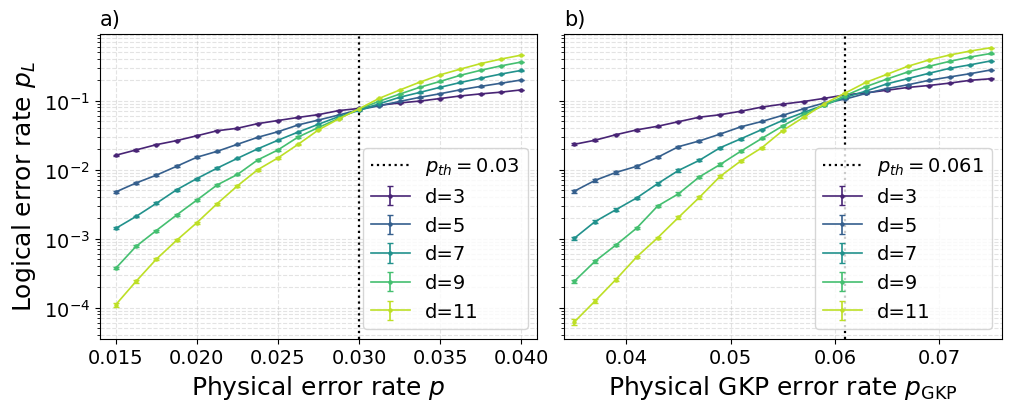

Figure caption: Triangular colour code below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.


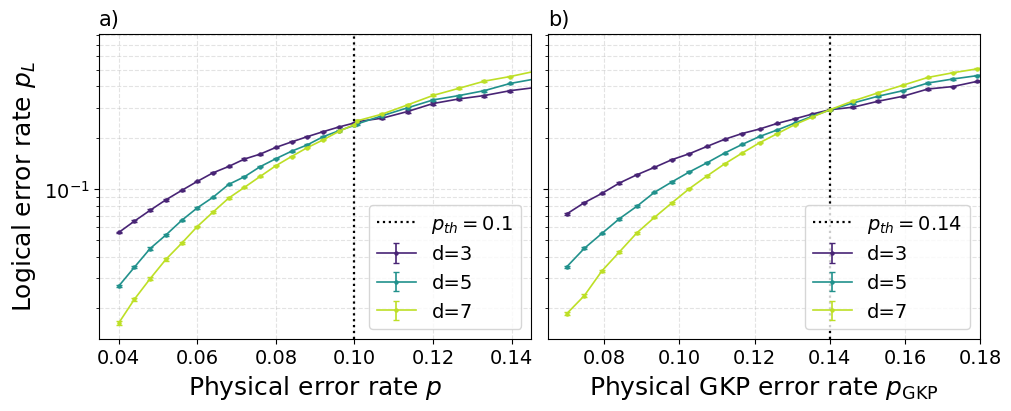

Figure caption: Triangular colour code logical error rates under explicit hard-GKP sampling. Viridis colour denotes code distance.


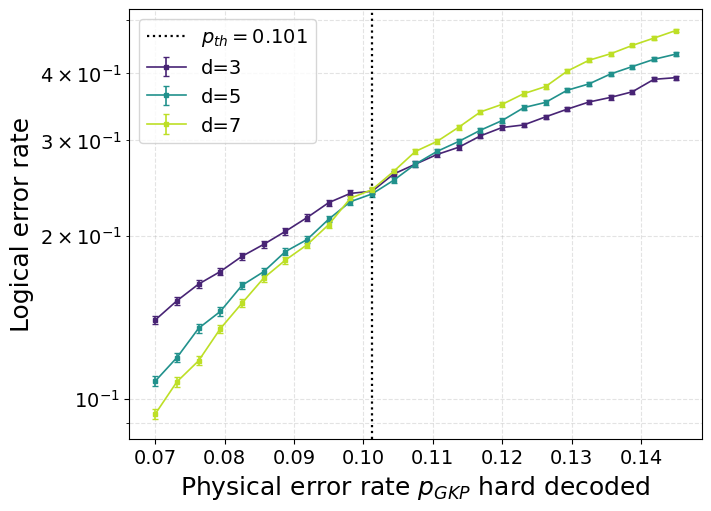

In [21]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def load_suppression_curve(filename):
    path = data_path(filename)
    final_path = path.with_name(f'final_{path.name}')
    if final_path.exists():
        path = final_path
        
    with path.open(encoding='utf-8') as file:
        saved = next(iter(json.load(file).values()))
        
    if isinstance(saved.get('sigma'), list):
        sigma = np.asarray(saved['sigma'], dtype=float)
        rate = np.asarray(saved['block_rate'], dtype=float)
        error = np.asarray(saved['block_error_bar'], dtype=float)
        physical = gkp_physical_error_rate(sigma)
    else:
        # Extract points safely
        points = sorted((point for point in saved.values() if 'sigma' in point), key=lambda point: point['sigma'])
        sigma = np.asarray([point['sigma'] for point in points], dtype=float)
        
        # Look inside the first dictionary element of the list to find the correct key string
        first_point = points[0] if points else {}
        rate_name = 'block_rate' if 'block_rate' in first_point else 'rate'
        error_name = 'block_error_bar' if 'block_error_bar' in first_point else 'error_bar'
        
        rate = np.asarray([point[rate_name] for point in points], dtype=float)
        error = np.asarray([point[error_name] for point in points], dtype=float)
        physical = np.asarray([point.get('physical_error_probability', np.nan) for point in points], dtype=float)
        
        missing = ~np.isfinite(physical)
        physical[missing] = gkp_physical_error_rate(sigma[missing])
        
    order = np.argsort(physical)
    return physical[order], rate[order], error[order]

def merge_curve_ranges(suppression_file, threshold_file):
    suppression_x, suppression_rate, suppression_error = load_suppression_curve(suppression_file)
    threshold_x, threshold_rate, threshold_error = load_suppression_curve(threshold_file)
    
    # Store using rounded floats uniformly to prevent precision lookup failures
    merged = {round(float(x), 12): (float(y), float(dy)) for x, y, dy in zip(suppression_x, suppression_rate, suppression_error)}
    
    for x_val, y, dy in zip(threshold_x, threshold_rate, threshold_error):
        if x_val > suppression_x.max() + 1e-12:
            merged[round(float(x_val), 12)] = (float(y), float(dy))
            
    # Extract sorted keys and mapped values safely
    sorted_keys = sorted(merged.keys())
    out_x = np.asarray(sorted_keys, dtype=float)
    out_rate = np.asarray([merged[k][0] for k in sorted_keys], dtype=float)
    out_error = np.asarray([merged[k][1] for k in sorted_keys], dtype=float)
    
    return out_x, out_rate, out_error

# --- Plotting Loop ---
suppression_families = [
    # Explicitly labeled Planar and 2D Toric in the family names
    ('Planar Surface code', (3, 5, 7, 9, 11), 'suppression_standard_surface_2d_d{d}_results.json', 'suppression_gkp_surface_2d_d{d}_results.json', 'standard_surface_2d_d{d}_results.json', 'gkp_surface_2d_d{d}_results.json', ((0.035, 0.140), (0.065, 0.180)), 'diss_suppression_surface_standard_vs_gkp.png'),
    ('2D Toric code', (3, 5, 7, 9, 11), 'suppression_standard_toric_2d_d{d}_results.json', 'suppression_gkp_toric_2d_d{d}_results.json', 'standard_toric_2d_d{d}_results.json', 'gkp_toric_2d_d{d}_results.json', ((0.035, 0.135), (0.065, 0.175)), 'diss_suppression_toric_standard_vs_gkp.png'),
    ('3D Toric code', (3, 5, 7, 9, 11), 'suppression_standard_toric_spacetime_d{d}_results.json', 'suppression_gkp_toric_spacetime_d{d}_results.json', 'suppression_standard_toric_spacetime_d{d}_results.json', 'suppression_gkp_toric_spacetime_d{d}_results.json', ((0.014, 0.041), (0.034, 0.076)), 'diss_suppression_toric_spacetime_standard_vs_gkp.png'),
    ('Triangular colour code', (3, 5, 7), 'suppression_standard_colour_code_triangular_xz_d{d}_results.json', 'suppression_gkp_colour_code_triangular_xz_d{d}_results.json', 'standard_colour_code_triangular_xz_d{d}_results.json', 'gkp_colour_code_triangular_xz_d{d}_results.json', ((0.035, 0.145), (0.065, 0.180)), 'diss_suppression_colour_standard_vs_gkp.png'),
]

for (family, distances, suppression_standard, suppression_gkp, threshold_standard, threshold_gkp, xlimits, output) in suppression_families:
    if family == '3D Toric code':
        # Automatically admit a distance after both pulled files contain the full sweep.
        complete_distances = []
        for distance in distances:
            point_counts = []
            for pattern in (suppression_standard, suppression_gkp):
                with data_path(pattern.format(d=distance)).open(encoding='utf-8') as file:
                    point_counts.append(len(next(iter(json.load(file).values()))))
            if min(point_counts) >= 21:
                complete_distances.append(distance)
        distances = tuple(complete_distances)
    # Print statement clearly clarifying Planar or 2D Toric details
    print_caption(f'{family} below-threshold suppression. a) Standard decoding. b) Soft-GKP decoding. Viridis colour denotes code distance; dotted lines mark the sampled convergence estimates.')
    
    colours = blue_green_colours(distances)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
    
    panel_setups = zip(axes, (suppression_standard, suppression_gkp), (threshold_standard, threshold_gkp), xlimits, ('a)', 'b)'))
    
    for axis, suppression_pattern, extension_pattern, xlim, panel_label in panel_setups:
        panel_curves = []
        for distance in distances:
            physical, rate, error = merge_curve_ranges(suppression_pattern.format(d=distance), extension_pattern.format(d=distance))
            panel_curves.append((physical, rate))
            
            visible = (physical > 0) & (rate > 0)
            axis.errorbar(physical[visible], rate[visible], yerr=error[visible], marker='o', ms=2.2, capsize=2, linewidth=1.2, color=colours[distance], label=f'd={distance}')
            
        threshold_val = closest_connected_point(panel_curves)
        axis.axvline(threshold_val, color='black', linestyle=':', linewidth=1.6, label=fr'$p_{{th}}={threshold_val:.3g}$')
        
        axis.set_title(panel_label, loc='left')
        axis.set_yscale('log')
        axis.set_xlim(*xlim)
        axis.grid(True, which='both', linestyle='--', alpha=0.35)
        axis.legend(fontsize=14)

    # Correct multi-axes indexing layout configurations
    axes[0].set_xlabel(r'Physical error rate $p$')
    axes[1].set_xlabel(r'Physical GKP error rate $p_{\mathrm{GKP}}$')
    
    # Unified y-axis label for all plots
    axes[0].set_ylabel('Logical error rate $p_L$')

    fig.savefig(output, dpi=300, bbox_inches='tight')
    plt.show()

    # Plot every explicit hard-GKP validation family pulled from the cluster.
    hard_setups = {
        'Planar Surface code': (
            'hard_gkp_surface_matched_d{d}_results.json',
            'hard_gkp_surface_2d_d{d}_results.json',
            'Planar surface code', 'diss_surface_hard_gkp.png'),
        '2D Toric code': (
            'hard_gkp_toric_matched_d{d}_results.json',
            'hard_gkp_toric_2d_d{d}_results.json',
            '2D toric code', 'diss_toric_hard_gkp.png'),
        'Triangular colour code': (
            'hard_gkp_colour_matched_d{d}_results.json',
            'hard_gkp_colour_code_triangular_xz_d{d}_results.json',
            'Triangular colour code', 'diss_colour_hard_gkp.png'),
    }
    if family in hard_setups:
        preferred_pattern, fallback_pattern, hard_label, hard_output = hard_setups[family]
        hard_paths = {distance: Path(prefer_existing(
            preferred_pattern.format(d=distance), fallback_pattern.format(d=distance)))
            for distance in distances}
        missing_hard = [path.name for path in hard_paths.values() if not path.exists()]
        if missing_hard:
            print(f'Hard-GKP {hard_label} figure skipped; missing: ' + ', '.join(missing_hard))
        else:
            print_caption(f'{hard_label} logical error rates under explicit hard-GKP sampling. Viridis colour denotes code distance.')
            hard_colours = blue_green_colours(distances)
            fig_hard, axis_hard = plt.subplots(figsize=(7, 5), constrained_layout=True)
            hard_curves = []
            for distance in distances:
                physical, rate, error = load_suppression_curve(hard_paths[distance])
                visible = (physical > 0) & (rate > 0)
                hard_curves.append((physical[visible], rate[visible]))
                axis_hard.errorbar(
                    physical[visible], rate[visible], yerr=error[visible],
                    marker='s', ms=3, capsize=2, linewidth=1.2,
                    color=hard_colours[distance], label=f'd={distance}',
                )
            hard_threshold = closest_connected_point(hard_curves)
            axis_hard.axvline(
                hard_threshold, color='black', linestyle=':', linewidth=1.6,
                label=fr'$p_{{th}}={hard_threshold:.3g}$',
            )
            axis_hard.set_xlabel(r'Physical error rate $p_{GKP}$ hard decoded')
            axis_hard.set_ylabel('Logical error rate')
            axis_hard.set_yscale('log')
            axis_hard.grid(True, which='both', linestyle='--', alpha=0.35)
            axis_hard.legend(fontsize=14)
            fig_hard.savefig(hard_output, dpi=300, bbox_inches='tight')
            plt.show()


## MKMN codes

The three MKMN parameter sets use different marker shapes because their distances and block sizes differ substantially. The common Viridis palette keeps them visually consistent with the other dissertation figures.


Figure caption: MKMN finite-size comparison. a) Standard decoding. b) Soft-GKP decoding. Marker shape distinguishes the quantum codes: circles $[[400,16,6]]$, squares $[[625,25,8]]$, and triangles $[[900,36,10]]$. With GKP-assisted decoding, the code-size curves remain separated to higher physical error rates, the larger encodings begin to outperform at higher error rates, and the below-threshold suppression becomes substantially steeper.


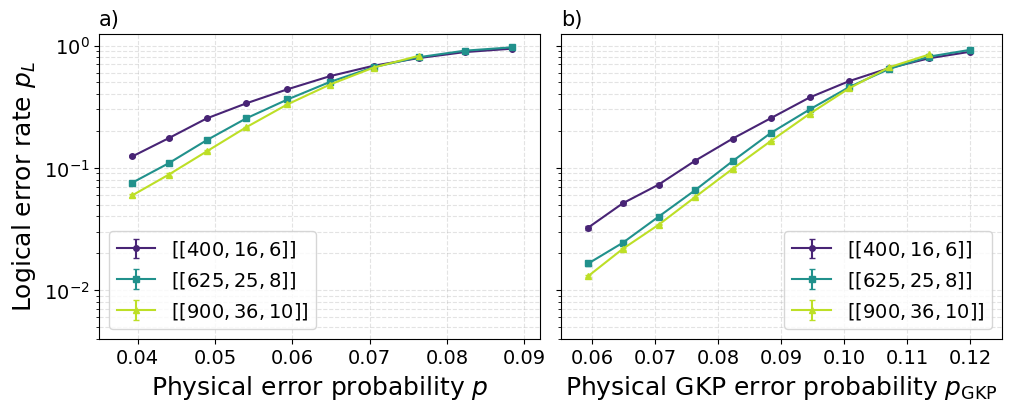

In [37]:
mkmn_seeds = ('16_4_6', '20_5_8', '24_6_10')
mkmn_quantum_labels = {
    '16_4_6': r'$[[400,16,6]]$',
    '20_5_8': r'$[[625,25,8]]$',
    '24_6_10': r'$[[900,36,10]]$',
}
mkmn_markers = dict(zip(mkmn_seeds, ('o', 's', '^')))
mkmn_colours = blue_green_colours(mkmn_seeds)
mkmn_files = [
    (mkmn_quantum_labels[seed], seed,
     prefer_existing(f'gkp_qldpc_mkmn_xz_standard_focused_{seed}_results.json',
                     f'gkp_qldpc_mkmn_xz_standard_quick_{seed}_results.json'),
     prefer_existing(f'gkp_qldpc_mkmn_xz_focused_{seed}_results.json',
                     f'gkp_qldpc_mkmn_xz_quick_{seed}_results.json'))
    for seed in mkmn_seeds
]

print_caption(r'MKMN finite-size comparison. a) Standard decoding. b) Soft-GKP decoding. Marker shape distinguishes the quantum codes: circles $[[400,16,6]]$, squares $[[625,25,8]]$, and triangles $[[900,36,10]]$. With GKP-assisted decoding, the code-size curves remain separated to higher physical error rates, the larger encodings begin to outperform at higher error rates, and the below-threshold suppression becomes substantially steeper.')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for label, seed, standard_file, gkp_file in mkmn_files:
    for axis, filename in zip(axes, (standard_file, gkp_file)):
        sigma, physical, rate, error = load_block_curve(filename)
        visible = (physical > 0) & (rate > 0)
        if axis is axes[1]:
            visible &= ~np.isclose(sigma, 0.45) & ~np.isclose(sigma, 0.46)
        axis.errorbar(physical[visible], rate[visible], yerr=error[visible],
                      marker=mkmn_markers[seed], ms=4, capsize=2,
                      color=mkmn_colours[seed], label=label)
for axis, panel_label, xlim in zip(axes, ('a)', 'b)'), ((0.035, 0.092), (0.055, 0.125))):
    axis.set_title(panel_label, loc='left')
    axis.set_yscale('log'); axis.set_xlim(*xlim); axis.set_ylim(4e-3, 1.25)
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=14)
axes[0].set_xlabel(r'Physical error probability $p$')
axes[1].set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
axes[0].set_ylabel('Logical error rate $p_L$')
fig.savefig('mkmn_quick_threshold_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Bivariate bicycle code with GKP decoding

These fixed-size results compare hard-decision and shot-specific analogue BP--OSD decoding for the $[[72,12,6]]$ bivariate bicycle code. They test decoder performance and the $X/Z$ squeezing trade-off; they do not constitute a threshold estimate.


Figure caption: Bivariate-bicycle $[[72,12,6]]$ block logical error. a) Hard-decision BP--OSD. b) Shot-specific analogue BP--OSD. Viridis colour denotes position squeezing.


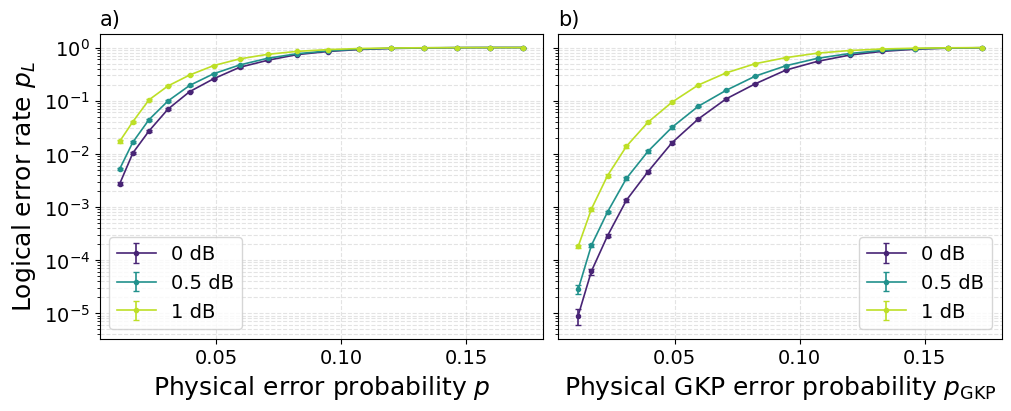

Figure caption: Improvement factor from shot-specific analogue information for the $[[72,12,6]]$ bivariate-bicycle code; values above one favour analogue decoding.


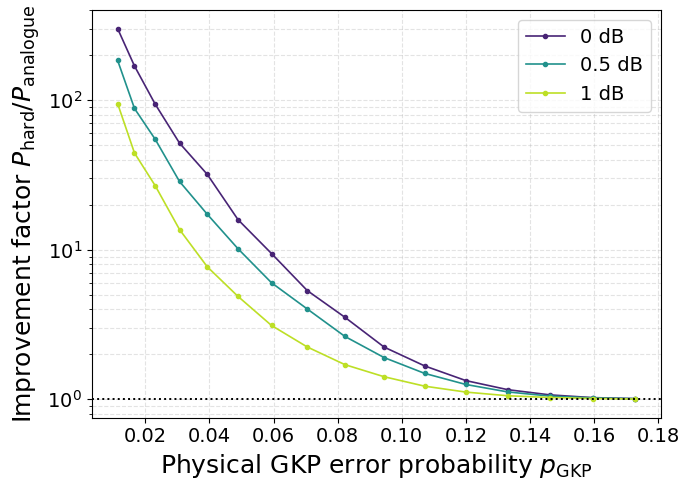

Figure caption: Analogue-decoded $[[72,12,6]]$ bivariate-bicycle sector failure rates versus position squeezing. a) X sector. b) Z sector.


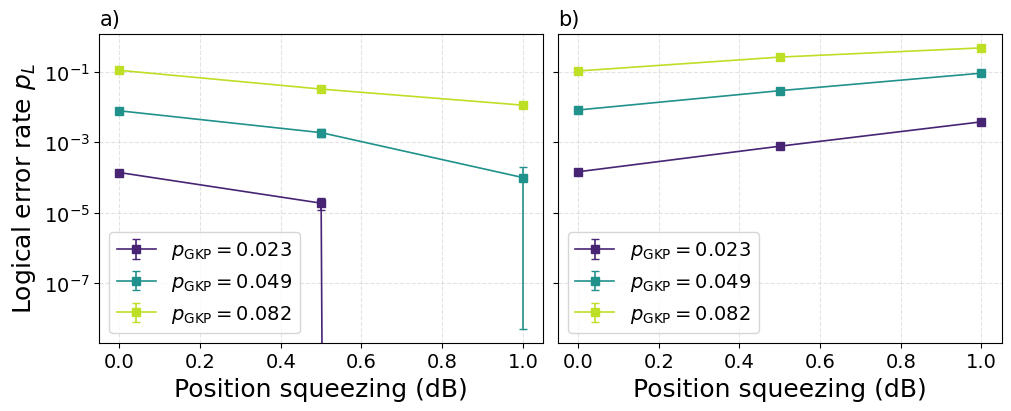

BB72 simulation setup


,Quantity,Value
0,Code,"[[72,12,6]] bivariate bicycle"
1,Check weight,6
2,Decoder,"BP--OSD, order 2"
3,Noise,Independent Gaussian GKP shifts
4,Syndrome measurements,Perfect
5,Squeezing,"0, 0.5, 1 dB"
6,$p_{\mathrm{GKP}}$ range,0.0113--0.1727 (16 points; unsqueezed-equivale...
7,Sampling,"At least 10,000 trials; target 300 block failu..."


BB72 representative block-error results


,$p_{\mathrm{GKP}}$,Squeezing (dB),Physical $p_X$,Physical $p_Z$,Hard block rate,Analogue block rate,Improvement factor
0,1.134e-02,0.0,1.134e-02,1.134e-02,2.720e-03,9.000e-06,302.24
1,1.134e-02,0.5,7.316e-03,1.683e-02,5.184e-03,2.800e-05,185.15
2,1.134e-02,1.0,4.497e-03,2.403e-02,1.713e-02,1.800e-04,95.18
3,4.891e-02,0.0,4.891e-02,4.891e-02,2.578e-01,1.622e-02,15.90
4,4.891e-02,0.5,3.697e-02,6.299e-02,3.208e-01,3.160e-02,10.15
5,4.891e-02,1.0,2.713e-02,7.922e-02,4.570e-01,9.380e-02,4.87
6,1.071e-01,0.0,1.071e-01,1.071e-01,9.182e-01,5.497e-01,1.67
7,1.071e-01,0.5,8.786e-02,1.282e-01,9.327e-01,6.266e-01,1.49
8,1.071e-01,1.0,7.062e-02,1.510e-01,9.581e-01,7.838e-01,1.22


In [23]:
# BB72: hard/analogue block error, analogue gain, X/Z trade-off, and tables
def load_bb72_result(decoder, squeezing):
    squeeze_tag = f'{squeezing:g}'.replace('.', 'p')
    path = data_path(f'bb72_gkp_{decoder}_sq{squeeze_tag}dB_results.json')
    with path.open(encoding='utf-8') as file:
        saved = json.load(file)
    points = sorted(
        (point for point in saved['points'].values() if 'block_rate' in point),
        key=lambda point: point['sigma'],
    )
    return saved, points

bb_squeezing = (0.0, 0.5, 1.0)
bb_data = {
    (decoder, squeezing): load_bb72_result(decoder, squeezing)
    for decoder in ('hard', 'analog') for squeezing in bb_squeezing
}
bb_colours = dict(zip(bb_squeezing, BLUE_GREEN_CMAP(np.linspace(0.10, 0.90, len(bb_squeezing)))))

print_caption(r'Bivariate-bicycle $[[72,12,6]]$ block logical error. a) Hard-decision BP--OSD. b) Shot-specific analogue BP--OSD. Viridis colour denotes position squeezing.')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for axis, decoder, panel_label in zip(axes, ('hard', 'analog'), ('a)', 'b)')):
    for squeezing in bb_squeezing:
        _, points = bb_data[(decoder, squeezing)]
        sigma = np.asarray([point['sigma'] for point in points])
        physical = gkp_physical_error_rate(sigma)
        rate = np.asarray([point['block_rate'] for point in points])
        error = np.asarray([point['block_standard_error'] for point in points])
        visible = rate > 0
        axis.errorbar(physical[visible], rate[visible], yerr=error[visible], marker='o',
                      ms=3, capsize=2, linewidth=1.2, color=bb_colours[squeezing],
                      label=fr'{squeezing:g} dB')
    axis.set_title(panel_label, loc='left')
    axis.set_xlabel(
        r'Physical error probability $p$' if decoder == 'hard'
        else r'Physical GKP error probability $p_{\mathrm{GKP}}$'
    )
    axis.set_yscale('log')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=14)
axes[0].set_ylabel('Logical error rate $p_L$')
fig.savefig('diss_bb72_hard_vs_analog.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption(r'Improvement factor from shot-specific analogue information for the $[[72,12,6]]$ bivariate-bicycle code; values above one favour analogue decoding.')
fig, axis = plt.subplots(figsize=(7, 5))
for squeezing in bb_squeezing:
    hard = {point['sigma']: point for point in bb_data[('hard', squeezing)][1]}
    analog = {point['sigma']: point for point in bb_data[('analog', squeezing)][1]}
    common = sorted(set(hard) & set(analog))
    gain = np.asarray([hard[s]['block_rate'] / analog[s]['block_rate']
                       if analog[s]['block_rate'] > 0 else np.nan for s in common])
    physical = gkp_physical_error_rate(common)
    axis.plot(physical, gain, marker='o', ms=3, linewidth=1.2,
              color=bb_colours[squeezing], label=fr'{squeezing:g} dB')
axis.axhline(1, color='black', linestyle=':', linewidth=1.4)
axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
axis.set_ylabel(r'Improvement factor $P_{\rm hard}/P_{\rm analogue}$')
axis.set_yscale('log')
axis.grid(True, which='both', linestyle='--', alpha=0.35)
axis.legend(fontsize=14)
fig.tight_layout()
fig.savefig('diss_bb72_analog_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

print_caption(r'Analogue-decoded $[[72,12,6]]$ bivariate-bicycle sector failure rates versus position squeezing. a) X sector. b) Z sector.')
selected_sigmas = (0.39, 0.45, 0.51)
bb_tradeoff_colours = dict(zip(
    selected_sigmas, BLUE_GREEN_CMAP(np.linspace(0.10, 0.90, len(selected_sigmas)))
))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
for axis, field, panel_label, sector in zip(axes, ('x_rate', 'z_rate'), ('a)', 'b)'), ('X', 'Z')):
    for sigma in selected_sigmas:
        rates, errors = [], []
        for squeezing in bb_squeezing:
            point = min(bb_data[('analog', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
            rates.append(point[field])
            errors.append(point[f'{field[0]}_standard_error'])
        axis.errorbar(bb_squeezing, rates, yerr=errors, marker='s', capsize=3,
                      linewidth=1.2, color=bb_tradeoff_colours[sigma],
                      label=fr'$p_{{\mathrm{{GKP}}}}={float(gkp_physical_error_rate(sigma)):.3f}$')
    axis.set_title(panel_label, loc='left')
    axis.set_xlabel('Position squeezing (dB)')
    axis.set_yscale('log')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
    axis.legend(fontsize=14)
axes[0].set_ylabel('Logical error rate $p_L$')
fig.savefig('diss_bb72_xz_squeezing_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()


print('BB72 simulation setup')
bb_setup_table = pd.DataFrame([
    ('Code', '[[72,12,6]] bivariate bicycle'),
    ('Check weight', '6'),
    ('Decoder', 'BP--OSD, order 2'),
    ('Noise', 'Independent Gaussian GKP shifts'),
    ('Syndrome measurements', 'Perfect'),
    ('Squeezing', '0, 0.5, 1 dB'),
    (r'$p_{\mathrm{GKP}}$ range', '0.0113--0.1727 (16 points; unsqueezed-equivalent coordinate)'),
    ('Sampling', 'At least 10,000 trials; target 300 block failures; maximum 1,000,000'),
], columns=('Quantity', 'Value'))
display(bb_setup_table)

print('BB72 representative block-error results')
representative_sigmas = (0.35, 0.45, 0.55)
rows = []
for sigma in representative_sigmas:
    for squeezing in bb_squeezing:
        hard_point = min(bb_data[('hard', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
        analog_point = min(bb_data[('analog', squeezing)][1], key=lambda item: abs(item['sigma'] - sigma))
        rows.append({
            r'$p_{\mathrm{GKP}}$': float(gkp_physical_error_rate(sigma)),
            'Squeezing (dB)': squeezing,
            r'Physical $p_X$': analog_point['physical_p_x'],
            r'Physical $p_Z$': analog_point['physical_p_z'],
            'Hard block rate': hard_point['block_rate'],
            'Analogue block rate': analog_point['block_rate'],
            'Improvement factor': hard_point['block_rate'] / analog_point['block_rate']
                                  if analog_point['block_rate'] > 0 else np.nan,
        })
bb_results_table = pd.DataFrame(rows)
bb_results_display = bb_results_table.copy()
for column in (r'$p_{\mathrm{GKP}}$', r'Physical $p_X$', r'Physical $p_Z$',
               'Hard block rate', 'Analogue block rate'):
    bb_results_display[column] = bb_results_display[column].map('{:.3e}'.format)
bb_results_display['Improvement factor'] = bb_results_display['Improvement factor'].map('{:.2f}'.format)
display(bb_results_display)


## Asymmetric codes

Squeezed-GKP bias is shown last, first for the fixed-aspect asymmetric HGP family and pilot code, then as a threshold-versus-squeezing summary.


Figure caption: Asymmetric HGP--GKP threshold scaling for position squeezing of a) 0 dB, b) 1 dB, c) 2 dB, and d) 3 dB. Curves correspond to increasing asymmetric distances with fixed ratio $d_Z/d_X=5/3$.


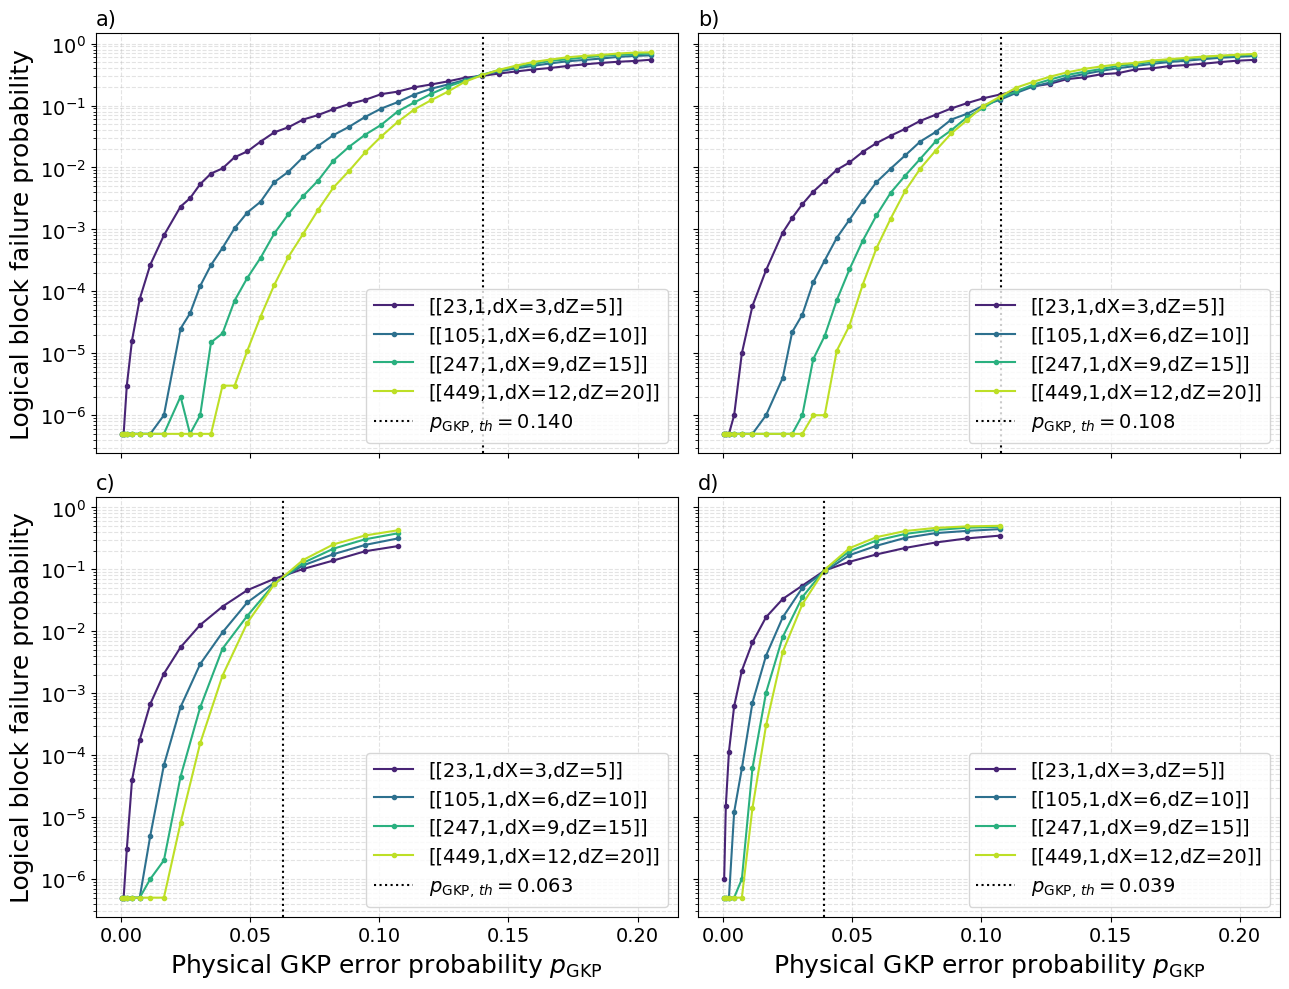

In [24]:
# Fixed-aspect asymmetric HGP family: distance scaling and crossing evidence
hgp_family = []
for filename in data_glob('asymmetric_hgp_qX_pZ_v2_*_sq*dB_results.json'):
    with open(filename, encoding='utf-8') as file:
        dataset = json.load(file)
    assert dataset['quadrature_pauli_convention'] == 'q displacement -> X; p displacement -> Z'
    if dataset['family'] == 'HGP of unequal repetition codes':
        hgp_family.append(dataset)

distance_order = {'[[23,1,dX=3,dZ=5]]': 3, '[[105,1,dX=6,dZ=10]]': 6,
                  '[[247,1,dX=9,dZ=15]]': 9, '[[449,1,dX=12,dZ=20]]': 12}

def adjacent_hgp_crossings(selected, minimum_rate=1e-3):
    # Interpolate where log(p_large/p_small) changes from negative to positive.
    curves = {}
    for dataset in selected:
        dx = distance_order[dataset['code']]
        curves[dx] = {round(p['sigma'], 8): max(p['block_rate'], 0.5/p['trials'])
                      for p in dataset['points'].values() if 'block_rate' in p}
    crossings = []
    for smaller, larger in ((3, 6), (6, 9), (9, 12)):
        previous = None
        for sigma in sorted(set(curves[smaller]) & set(curves[larger])):
            p_small, p_large = curves[smaller][sigma], curves[larger][sigma]
            if max(p_small, p_large) < minimum_rate:
                continue
            difference = np.log(p_large) - np.log(p_small)
            if previous is not None and previous[1] < 0 <= difference:
                sigma0, difference0 = previous
                crossing = sigma0 + (sigma-sigma0)*(-difference0)/(difference-difference0)
                crossings.append(crossing)
                break
            previous = (sigma, difference)
    return crossings

print_caption(r'Asymmetric HGP--GKP threshold scaling for position squeezing of a) 0 dB, b) 1 dB, c) 2 dB, and d) 3 dB. Curves correspond to increasing asymmetric distances with fixed ratio $d_Z/d_X=5/3$.')
hgp_threshold_summary = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
for panel_index, (axis, squeezing) in enumerate(zip(axes.flat, (0, 1, 2, 3))):
    selected = sorted((d for d in hgp_family if float(d['squeezing_db']) == squeezing),
                      key=lambda d: distance_order[d['code']])
    crossings = adjacent_hgp_crossings(selected)
    threshold = float(np.mean(crossings))
    spread = float(np.std(crossings, ddof=1))
    physical_crossings = np.asarray(gkp_physical_error_rate(crossings), dtype=float)
    physical_threshold = float(gkp_physical_error_rate(threshold))
    physical_spread = float(np.std(physical_crossings, ddof=1))
    hgp_threshold_summary[squeezing] = {
        'threshold': threshold, 'spread': spread, 'pair_crossings': crossings,
        'physical_threshold': physical_threshold, 'physical_spread': physical_spread,
        'physical_pair_crossings': physical_crossings.tolist(),
    }
    for dataset in selected:
        points = sorted((p for p in dataset['points'].values() if 'block_rate' in p), key=lambda p: p['sigma'])
        rates = [max(p['block_rate'], 0.5 / p['trials']) for p in points]
        physical = gkp_physical_error_rate([p['sigma'] for p in points])
        axis.plot(physical, rates, 'o-', ms=3, color=BLUE_GREEN_CMAP(0.10 + 0.80 * (distance_order[dataset['code']] - 3) / 9), label=dataset['code'])
    axis.axvline(physical_threshold, color='black', linestyle=':', linewidth=1.5,
                 label=fr'$p_{{\mathrm{{GKP}},\,th}}={physical_threshold:.3f}$')
    axis.set_yscale('log'); axis.set_title(f"{'abcd'[panel_index]})", loc='left')
    axis.grid(True, which='both', linestyle='--', alpha=0.35); axis.legend(fontsize=14)
for axis in axes[-1]: axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
for axis in axes[:, 0]: axis.set_ylabel('Logical block failure probability')
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_thresholds.png', dpi=300, bbox_inches='tight'); plt.show()


Figure caption: Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: logical block failure versus physical GKP error probability for several squeezing values.
Figure caption: Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: X/Z logical-sector trade-off under position squeezing.


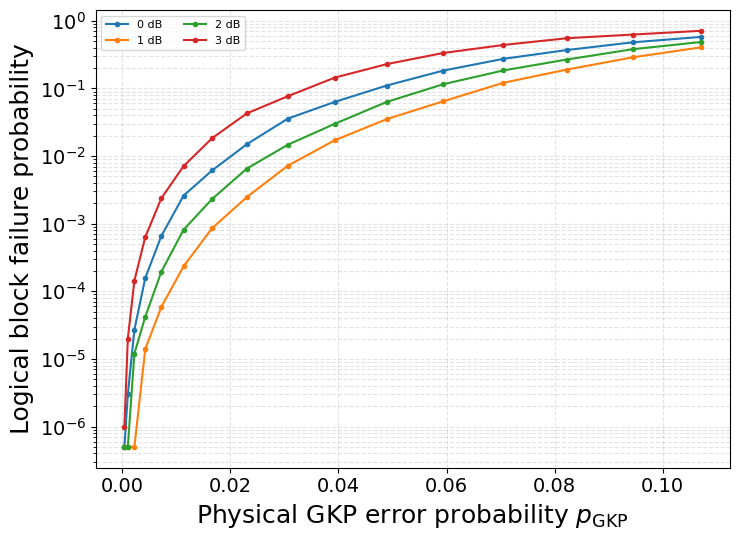

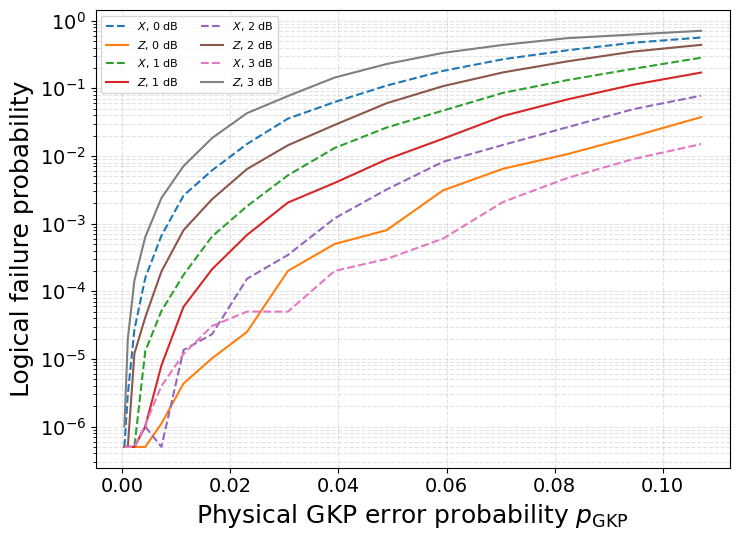

In [25]:
print_caption(r'Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: logical block failure versus physical GKP error probability for several squeezing values.')
# Small non-surface pilot: HGP(rep[5,1,5], Hamming[7,4,3]) = [[47,4,3,5]]
pilot = []
for filename in data_glob('asymmetric_hgp_qX_pZ_v2_rep5xhamming7_sq*dB_results.json'):
    with open(filename, encoding='utf-8') as file:
        pilot.append(json.load(file))
fig_block, axis_block = plt.subplots(figsize=(7.5, 5.5))
fig_xz, axis_xz = plt.subplots(figsize=(7.5, 5.5))
for dataset in sorted(pilot, key=lambda d: d['squeezing_db']):
    points = sorted((p for p in dataset['points'].values() if 'block_rate' in p), key=lambda p: p['sigma'])
    squeezing = dataset['squeezing_db']
    physical = gkp_physical_error_rate([p['sigma'] for p in points])
    axis_block.plot(physical,
                 [max(p['block_rate'], 0.5/p['trials']) for p in points],
                 'o-', ms=3, label=f'{squeezing:g} dB')
    axis_xz.plot(physical,
                 [max(p['x_rate'], 0.5/p['trials']) for p in points],
                 '--', label=fr'$X$, {squeezing:g} dB')
    axis_xz.plot(physical,
                 [max(p['z_rate'], 0.5/p['trials']) for p in points],
                 '-', label=fr'$Z$, {squeezing:g} dB')
for axis in (axis_block, axis_xz):
    axis.set_yscale('log'); axis.set_xlabel(r'Physical GKP error probability $p_{\mathrm{GKP}}$')
    axis.grid(True, which='both', linestyle='--', alpha=0.35); axis.legend(fontsize=8, ncol=2)
axis_block.set_ylabel('Logical block failure probability')
fig_block.tight_layout()
fig_block.savefig('diss_asymmetric_hgp_pilot_block_failure.png', dpi=300, bbox_inches='tight')
axis_xz.set_ylabel('Logical failure probability')
print_caption(r'Asymmetric HGP--GKP pilot $[[47,4,d_X=3,d_Z=5]]$: X/Z logical-sector trade-off under position squeezing.')
fig_xz.tight_layout()
fig_xz.savefig('diss_asymmetric_hgp_pilot_xz_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()


### Asymmetric-HGP threshold versus squeezing

Each estimate is the mean of the three adjacent-size crossings. The quoted spread measures finite-size drift rather than a full statistical confidence interval.


,Position squeezing (dB),Estimated physical threshold,Adjacent-pair spread,Pair crossings,Change from 0 dB (%)
0,0,0.1403,0.0033,"0.1377, 0.1392, 0.1439",+0.0%
1,1,0.1077,0.0117,"0.1209, 0.1042, 0.0983",-23.2%
2,2,0.0628,0.0023,"0.0650, 0.0630, 0.0605",-55.2%
3,3,0.0392,0.0013,"0.0404, 0.0378, 0.0395",-72.0%


Figure caption: Estimated asymmetric HGP--GKP threshold versus position squeezing. Error bars show the spread among adjacent-size crossings; the dotted line is the unsqueezed reference.


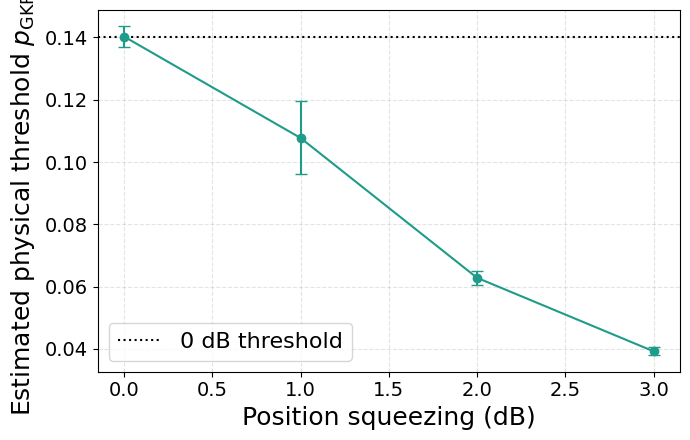

In [26]:
# Threshold-versus-squeezing table, calculated from the guide lines above
baseline_hgp_threshold = hgp_threshold_summary[0]['physical_threshold']
hgp_squeezing_threshold_table = pd.DataFrame([
    {
        'Position squeezing (dB)': squeezing,
        'Estimated physical threshold': values['physical_threshold'],
        'Adjacent-pair spread': values['physical_spread'],
        'Pair crossings': ', '.join(f'{value:.4f}' for value in values['physical_pair_crossings']),
        'Change from 0 dB (%)': 100*(values['physical_threshold']/baseline_hgp_threshold - 1),
    }
    for squeezing, values in sorted(hgp_threshold_summary.items())
])
hgp_squeezing_threshold_display = hgp_squeezing_threshold_table.copy()
hgp_squeezing_threshold_display['Estimated physical threshold'] = hgp_squeezing_threshold_display['Estimated physical threshold'].map('{:.4f}'.format)
hgp_squeezing_threshold_display['Adjacent-pair spread'] = hgp_squeezing_threshold_display['Adjacent-pair spread'].map('{:.4f}'.format)
hgp_squeezing_threshold_display['Change from 0 dB (%)'] = hgp_squeezing_threshold_display['Change from 0 dB (%)'].map('{:+.1f}%'.format)
display(hgp_squeezing_threshold_display)

print_caption('Estimated asymmetric HGP--GKP threshold versus position squeezing. Error bars show the spread among adjacent-size crossings; the dotted line is the unsqueezed reference.')
fig, axis = plt.subplots(figsize=(7, 4.5))
axis.errorbar(hgp_squeezing_threshold_table['Position squeezing (dB)'],
              hgp_squeezing_threshold_table['Estimated physical threshold'],
              yerr=hgp_squeezing_threshold_table['Adjacent-pair spread'],
              fmt='o-', capsize=4, color=BLUE_GREEN_CMAP(0.55))
axis.axhline(baseline_hgp_threshold, color='black', linestyle=':', label='0 dB threshold')
axis.set_xlabel('Position squeezing (dB)'); axis.set_ylabel(r'Estimated physical threshold $p_{\mathrm{GKP},th}$')
axis.grid(True, linestyle='--', alpha=0.35); axis.legend()
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_threshold_vs_squeezing.png', dpi=300, bbox_inches='tight'); plt.show()


### Asymmetric-HGP comparison across all distance ratios

These cells include the $5{:}3$, $2{:}1$, $5{:}2$, and $3{:}1$ scalable families. Negative squeezing points are retained as orientation controls. Thresholds are means of adjacent-size crossings; the spread is a finite-size diagnostic rather than a statistical confidence interval.


,Distance ratio,Position squeezing (dB),Estimated physical threshold,Crossing spread,Change from 0 dB (%),Pair crossings
5,2:1,0.000,0.1397,0.0046,+0.0%,"0.1374, 0.1397, 0.1420"
6,2:1,0.250,0.1419,0.0016,+1.6%,"0.1409, 0.1423, 0.1425"
7,2:1,0.500,0.1414,0.0023,+1.2%,"0.1426, 0.1403, 0.1414"
8,2:1,0.750,0.1280,0.0240,-8.4%,"0.1366, 0.1347, 0.1127"
9,2:1,1.000,0.1124,0.0266,-19.5%,"0.1270, 0.1099, 0.1004"
10,2:1,1.250,0.0974,0.0227,-30.3%,"0.1119, 0.0892, 0.0909"
11,2:1,1.500,0.0861,0.0189,-38.3%,"0.0969, 0.0836, 0.0780"
21,3:1,-0.500,0.1316,0.0660,-4.1%,"0.1055, 0.1179, 0.1715"
22,3:1,-0.250,0.1257,0.0073,-8.4%,"0.1227, 0.1242, 0.1301"
23,3:1,0.000,0.1372,0.0127,+0.0%,"0.1307, 0.1358, 0.1434, 0.1389"


Figure caption: Estimated asymmetric HGP--GKP physical threshold versus position squeezing for four fixed distance-ratio families. Error bars show half the spread of adjacent-size crossings; negative squeezing values are orientation controls.


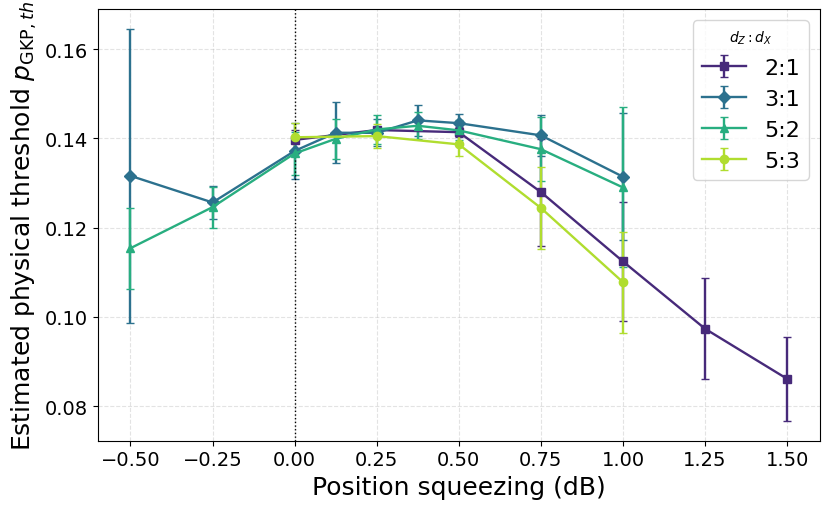

In [27]:
# All-ratio threshold comparison and dissertation-ready table
from plot_asymmetric_hgp_threshold import FAMILIES, estimate_threshold, load_datasets

all_ratio_datasets = load_datasets(Path('.'))
all_ratio_rows = []
for family_key, (family_label, minimum_squeezing, maximum_squeezing) in FAMILIES.items():
    family_estimates = {}
    for squeezing, codes in sorted(all_ratio_datasets[family_key].items()):
        if minimum_squeezing <= squeezing <= maximum_squeezing:
            estimate = estimate_threshold(codes)
            if estimate is not None:
                physical_crossings = np.asarray(gkp_physical_error_rate(estimate['pairwise_crossings']), dtype=float)
                family_estimates[squeezing] = {
                    'physical_threshold': float(np.mean(physical_crossings)),
                    'physical_spread': float(np.ptp(physical_crossings)),
                    'physical_crossings': physical_crossings.tolist(),
                }
    if not family_estimates or 0 not in family_estimates:
        continue
    baseline = family_estimates[0]['physical_threshold']
    for squeezing, values in family_estimates.items():
        all_ratio_rows.append({
            'Distance ratio': family_label.replace(' family', ''),
            'Position squeezing (dB)': squeezing,
            'Estimated physical threshold': values['physical_threshold'],
            'Crossing spread': values['physical_spread'],
            'Change from 0 dB (%)': 100*(values['physical_threshold']/baseline - 1),
            'Pair crossings': ', '.join(f'{value:.4f}' for value in values['physical_crossings']),
        })

all_ratio_threshold_table = pd.DataFrame(all_ratio_rows).sort_values(['Distance ratio', 'Position squeezing (dB)'])
all_ratio_threshold_table.to_csv('diss_asymmetric_hgp_all_ratios_thresholds.csv', index=False)
all_ratio_display = all_ratio_threshold_table.copy()
for column in ('Estimated physical threshold', 'Crossing spread'):
    all_ratio_display[column] = all_ratio_display[column].map('{:.4f}'.format)
all_ratio_display['Change from 0 dB (%)'] = all_ratio_display['Change from 0 dB (%)'].map('{:+.1f}%'.format)
display(all_ratio_display)

print_caption(r'Estimated asymmetric HGP--GKP physical threshold versus position squeezing for four fixed distance-ratio families. Error bars show half the spread of adjacent-size crossings; negative squeezing values are orientation controls.')
fig, axis = plt.subplots(figsize=(8.4, 5.2))
markers = {'5:3': 'o', '2:1': 's', '5:2': '^', '3:1': 'D'}
for index, (ratio, rows) in enumerate(all_ratio_threshold_table.groupby('Distance ratio')):
    rows = rows.sort_values('Position squeezing (dB)')
    axis.errorbar(rows['Position squeezing (dB)'], rows['Estimated physical threshold'],
                  yerr=rows['Crossing spread']/2, marker=markers[ratio], capsize=3,
                  linewidth=1.7, color=BLUE_GREEN_CMAP(0.12 + 0.76*index/3), label=ratio)
axis.axvline(0, color='black', linestyle=':', linewidth=1)
axis.set_xlabel('Position squeezing (dB)')
axis.set_ylabel(r'Estimated physical threshold $p_{\mathrm{GKP},th}$')
axis.grid(True, linestyle='--', alpha=0.35); axis.legend(title=r'$d_Z:d_X$')
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_all_ratios_threshold_vs_squeezing.png', dpi=300, bbox_inches='tight'); plt.show()


,Distance ratio,Position squeezing (dB),Code length n,Logical block rate,Suppression factor
0,5:3,0.000,449,0.002061,1.000000
1,5:3,0.250,449,0.000755,2.728630
2,5:3,0.500,449,0.000892,2.310275
3,5:3,0.750,449,0.002829,0.728637
4,5:3,1.000,449,0.009570,0.215410
5,2:1,0.000,541,0.002435,1.000000
6,2:1,0.250,541,0.000810,3.006121
7,2:1,0.500,541,0.000350,6.966621
8,2:1,0.750,541,0.001042,2.338140
9,2:1,1.000,541,0.004375,0.556582


Figure caption: Logical-error suppression from squeezing at fixed base noise $\sigma=0.50$, using the largest member of each asymmetric HGP family whose sampled range contains this point. Values above one indicate improvement over the unsqueezed result.


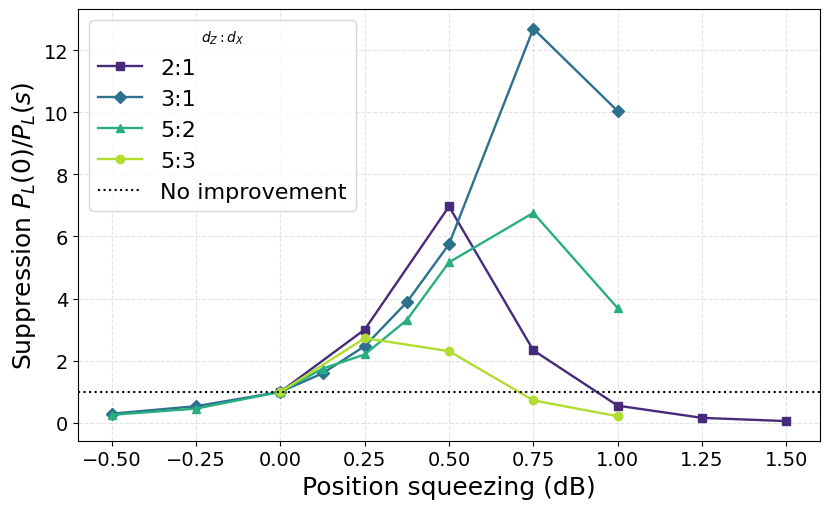

In [28]:
# Below-threshold benefit at fixed base noise: largest code in each family
target_sigma = 0.50
suppression_rows = []
for family_key, (family_label, minimum_squeezing, maximum_squeezing) in FAMILIES.items():
    rates = {}
    for squeezing, codes in all_ratio_datasets[family_key].items():
        if not minimum_squeezing <= squeezing <= maximum_squeezing:
            continue
        # Use the largest code whose sampled sigma range contains the target.
        # The newer 25x10 and 30x10 threshold runs start at sigma=0.55, so
        # they cannot support a sigma=0.50 suppression comparison.
        eligible = []
        for code in codes:
            points = sorted((p for p in code['points'] if 'block_rate' in p), key=lambda p: p['sigma'])
            if not points or not points[0]['sigma'] <= target_sigma <= points[-1]['sigma']:
                continue
            sigmas = np.asarray([p['sigma'] for p in points], dtype=float)
            block_rates = np.asarray([max(p['block_rate'], 0.5/p['trials']) for p in points])
            rate = float(np.exp(np.interp(target_sigma, sigmas, np.log(block_rates))))
            eligible.append((code['n'], rate))
        if eligible:
            rates[squeezing] = max(eligible, key=lambda item: item[0])
    if 0 not in rates:
        continue
    baseline_n, baseline_rate = rates[0]
    for squeezing, (code_n, rate) in sorted(rates.items()):
        suppression_rows.append({
            'Distance ratio': family_label.replace(' family', ''),
            'Position squeezing (dB)': squeezing,
            'Code length n': code_n,
            'Logical block rate': rate,
            'Suppression factor': baseline_rate/rate,
        })
suppression_table = pd.DataFrame(suppression_rows)
display(suppression_table)
print_caption(r'Logical-error suppression from squeezing at fixed base noise $\sigma=0.50$, using the largest member of each asymmetric HGP family whose sampled range contains this point. Values above one indicate improvement over the unsqueezed result.')
fig, axis = plt.subplots(figsize=(8.4, 5.2))
for index, (ratio, rows) in enumerate(suppression_table.groupby('Distance ratio')):
    rows = rows.sort_values('Position squeezing (dB)')
    axis.plot(rows['Position squeezing (dB)'], rows['Suppression factor'],
              marker=markers[ratio], linewidth=1.7,
              color=BLUE_GREEN_CMAP(0.12 + 0.76*index/3), label=ratio)
axis.axhline(1, color='black', linestyle=':', label='No improvement')
axis.set_xlabel('Position squeezing (dB)'); axis.set_ylabel(r'Suppression $P_L(0)/P_L(s)$')
axis.grid(True, linestyle='--', alpha=0.35); axis.legend(title=r'$d_Z:d_X$')
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_squeezing_suppression.png', dpi=300, bbox_inches='tight'); plt.show()


### Logical X/Z trade-off for the new asymmetric families

This figure uses only the all-ratio datasets above. It shows how positive squeezing suppresses logical $X$ failure while increasing logical $Z$ failure, and where the asymmetric outer code achieves the best balance.


Figure caption: Logical a) $X$- and b) $Z$-failure probabilities versus position squeezing at fixed base noise $\sigma=0.50$. Each curve uses the largest member of that asymmetric HGP family whose sampled range contains this point.


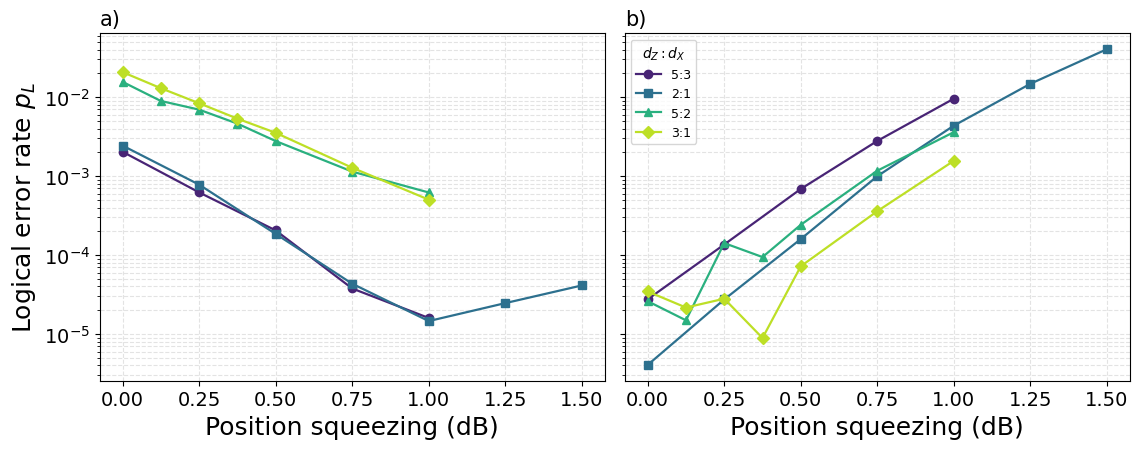

In [29]:
# One compact two-panel figure: four ratios per panel, newer data only
target_sigma = 0.50
xz_rows = []
for family_key, (family_label, minimum_squeezing, maximum_squeezing) in FAMILIES.items():
    ratio = family_label.replace(' family', '')
    for squeezing, codes in sorted(all_ratio_datasets[family_key].items()):
        if not 0 <= squeezing <= maximum_squeezing:
            continue  # omit the negative-orientation controls from this compact figure
        eligible = []
        for code in codes:
            points = sorted((p for p in code['points'] if 'x_rate' in p and 'z_rate' in p),
                            key=lambda p: p['sigma'])
            if not points or not points[0]['sigma'] <= target_sigma <= points[-1]['sigma']:
                continue
            sigmas = np.asarray([p['sigma'] for p in points], dtype=float)
            x_rates = np.asarray([max(p['x_rate'], 0.5/p['trials']) for p in points])
            z_rates = np.asarray([max(p['z_rate'], 0.5/p['trials']) for p in points])
            x_relative = np.asarray([p['x_error_bar']/max(p['x_rate'], 0.5/p['trials']) for p in points])
            z_relative = np.asarray([p['z_error_bar']/max(p['z_rate'], 0.5/p['trials']) for p in points])
            x_rate = float(np.exp(np.interp(target_sigma, sigmas, np.log(x_rates))))
            z_rate = float(np.exp(np.interp(target_sigma, sigmas, np.log(z_rates))))
            x_bar = x_rate*float(np.interp(target_sigma, sigmas, x_relative))
            z_bar = z_rate*float(np.interp(target_sigma, sigmas, z_relative))
            eligible.append((code['n'], x_rate, z_rate, x_bar, z_bar))
        if eligible:
            code_n, x_rate, z_rate, x_bar, z_bar = max(eligible, key=lambda item: item[0])
            xz_rows.append({'Distance ratio': ratio, 'Position squeezing (dB)': squeezing,
                            'Code length n': code_n, 'X rate': x_rate, 'Z rate': z_rate,
                            'X error': x_bar, 'Z error': z_bar})
xz_table = pd.DataFrame(xz_rows)

print_caption(r'Logical a) $X$- and b) $Z$-failure probabilities versus position squeezing at fixed base noise $\sigma=0.50$. Each curve uses the largest member of that asymmetric HGP family whose sampled range contains this point.')
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True, sharey=True)
ratio_order = ('5:3', '2:1', '5:2', '3:1')
ratio_colours = dict(zip(ratio_order, BLUE_GREEN_CMAP(np.linspace(0.10, 0.90, 4))))
for ratio in ratio_order:
    rows = xz_table[xz_table['Distance ratio'] == ratio].sort_values('Position squeezing (dB)')
    if rows.empty:
        continue
    for axis, sector in zip(axes, ('X', 'Z')):
        axis.plot(rows['Position squeezing (dB)'], rows[f'{sector} rate'],
                  marker=markers[ratio], linewidth=1.6,
                  color=ratio_colours[ratio], label=ratio)
for panel, (axis, sector) in enumerate(zip(axes, ('X', 'Z'))):
    axis.set_yscale('log'); axis.set_xlabel('Position squeezing (dB)')
    axis.set_title(f"{'ab'[panel]})", loc='left')
    axis.grid(True, which='both', linestyle='--', alpha=0.35)
axes[0].set_ylabel('Logical error rate $p_L$')
axes[1].legend(title=r'$d_Z:d_X$', fontsize=9)
fig.tight_layout(); fig.savefig('diss_asymmetric_hgp_xz_failure_vs_squeezing.png', dpi=300, bbox_inches='tight'); plt.show()


### Size scaling of the squeezing benefit for the 3:1 family

The distance ratio and squeezing are held fixed while the code family grows. The comparison uses the unsqueezed channel and the family-level optimum of $0.75$ dB at base noise $\sigma=0.58$.


Figure caption: Size scaling of the squeezing benefit for the $d_Z:d_X=3{:}1$ asymmetric HGP family at fixed base noise $\sigma=0.58$. a) Logical block failure without squeezing and at the family-level optimum of $0.75$ dB. b) Suppression factor relative to the unsqueezed channel.


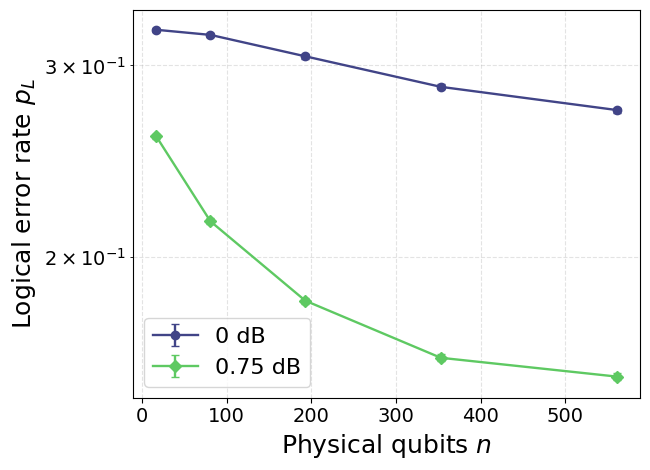

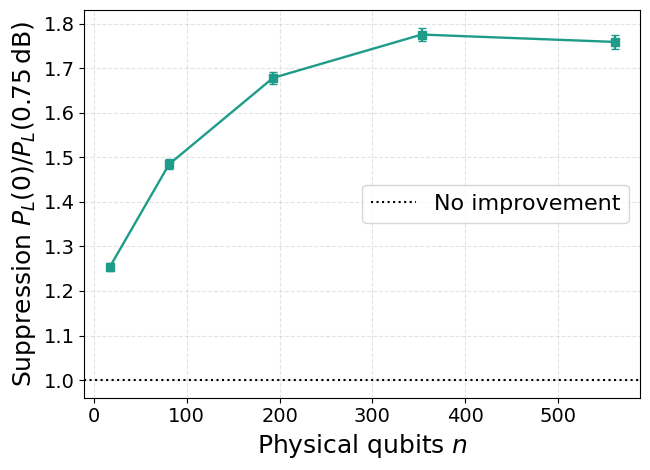

,n,squeezing_db,block_rate,error_bar
0,17,0.00,0.32350,0.001479
1,81,0.00,0.32001,0.001475
2,193,0.00,0.30581,0.001457
3,353,0.00,0.28666,0.001430
4,561,0.00,0.27289,0.001409
5,17,0.75,0.25810,0.001384
6,81,0.75,0.21558,0.001300
7,193,0.75,0.18221,0.001221
8,353,0.75,0.16145,0.001164
9,561,0.75,0.15514,0.001145


In [30]:
# 3:1 family: logical scaling and squeezing gain at fixed sigma
target_sigma = 0.58
selected_squeezing = (0.0, 0.75)
ratio3_key = 'HGP of unequal repetition codes (dZ:dX=3:1)'
ratio3_rows = []
for squeezing in selected_squeezing:
    for code in sorted(all_ratio_datasets[ratio3_key].get(squeezing, []), key=lambda item: item['n']):
        points = sorted((p for p in code['points'] if 'block_rate' in p), key=lambda p: p['sigma'])
        if not points or not points[0]['sigma'] <= target_sigma <= points[-1]['sigma']:
            continue
        sigmas = np.asarray([p['sigma'] for p in points], dtype=float)
        rates = np.asarray([max(p['block_rate'], 0.5/p['trials']) for p in points])
        relative_errors = np.asarray([p['block_error_bar']/max(p['block_rate'], 0.5/p['trials'])
                                      for p in points])
        rate = float(np.exp(np.interp(target_sigma, sigmas, np.log(rates))))
        error = rate*float(np.interp(target_sigma, sigmas, relative_errors))
        ratio3_rows.append({'n': code['n'], 'squeezing_db': squeezing,
                            'block_rate': rate, 'error_bar': error})
ratio3_scaling = pd.DataFrame(ratio3_rows).sort_values(['squeezing_db', 'n'])

unsqueezed = ratio3_scaling[ratio3_scaling['squeezing_db'] == 0].set_index('n')
squeezed = ratio3_scaling[ratio3_scaling['squeezing_db'] == 0.75].set_index('n')
common_n = unsqueezed.index.intersection(squeezed.index).sort_values()
gain = unsqueezed.loc[common_n, 'block_rate']/squeezed.loc[common_n, 'block_rate']
gain_error = gain*np.sqrt(
    (unsqueezed.loc[common_n, 'error_bar']/unsqueezed.loc[common_n, 'block_rate'])**2
    + (squeezed.loc[common_n, 'error_bar']/squeezed.loc[common_n, 'block_rate'])**2)

print_caption(r'Size scaling of the squeezing benefit for the $d_Z:d_X=3{:}1$ asymmetric HGP family at fixed base noise $\sigma=0.58$. a) Logical block failure without squeezing and at the family-level optimum of $0.75$ dB. b) Suppression factor relative to the unsqueezed channel.')
fig_scaling, axis_scaling = plt.subplots(figsize=(6.6, 4.8))
for squeezing, colour, marker in ((0.0, BLUE_GREEN_CMAP(0.20), 'o'),
                                   (0.75, BLUE_GREEN_CMAP(0.75), 'D')):
    rows = ratio3_scaling[ratio3_scaling['squeezing_db'] == squeezing]
    axis_scaling.errorbar(rows['n'], rows['block_rate'], yerr=rows['error_bar'],
                     marker=marker, capsize=3, linewidth=1.7, color=colour,
                     label=f'{squeezing:g} dB')
axis_scaling.set_yscale('log'); axis_scaling.set_xlabel('Physical qubits $n$')
axis_scaling.set_ylabel('Logical error rate $p_L$')
axis_scaling.grid(True, which='both', linestyle='--', alpha=0.35); axis_scaling.legend()
fig_scaling.tight_layout(); fig_scaling.savefig('diss_asymmetric_hgp_ratio3_logical_scaling.png', dpi=300, bbox_inches='tight')
plt.show()

fig_gain, axis_gain = plt.subplots(figsize=(6.6, 4.8))
axis_gain.errorbar(common_n, gain, yerr=gain_error, marker='s', capsize=3,
                 linewidth=1.7, color=BLUE_GREEN_CMAP(0.55))
axis_gain.axhline(1, color='black', linestyle=':', label='No improvement')
axis_gain.set_xlabel('Physical qubits $n$'); axis_gain.set_ylabel(r'Suppression $P_L(0)/P_L(0.75\,\mathrm{dB})$')
axis_gain.grid(True, which='both', linestyle='--', alpha=0.35); axis_gain.legend()
fig_gain.tight_layout(); fig_gain.savefig('diss_asymmetric_hgp_ratio3_suppression_vs_size.png', dpi=300, bbox_inches='tight')
plt.show()
display(ratio3_scaling)


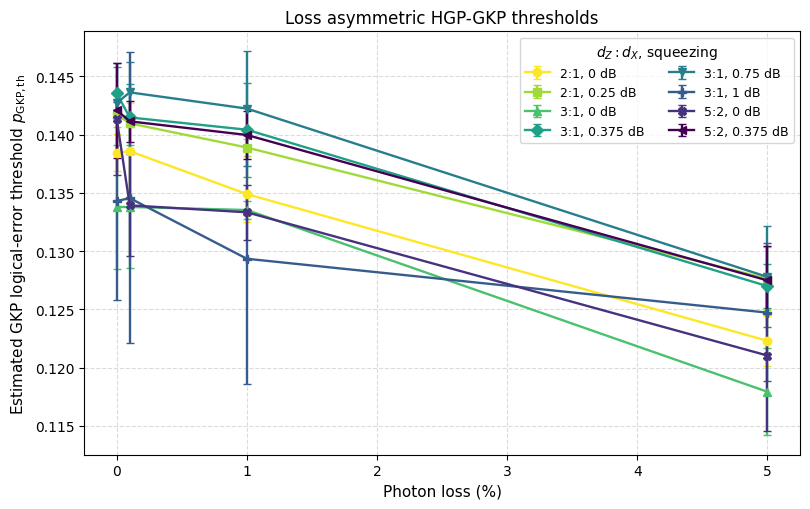

Figure caption: Estimated GKP logical-error probability thresholds for asymmetric HGP-GKP code families under compensated bosonic photon loss. Error bars are the adjacent-size crossing spread transformed through the GKP Gaussian-displacement conversion.


In [31]:
# Loss-aware asymmetric HGP threshold figure -- edit the style settings here.
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
from plot_asymmetric_hgp_loss_threshold import load_datasets
from plot_asymmetric_hgp_threshold import estimate_threshold

def plot_loss_thresholds(
    directory=Path('.'),
    figsize=(8.2, 5.2),
    colours=None,
    markers=('o', 's', '^', 'D', 'v', 'P', 'X', '<'),
    linewidth=1.7,
    markersize=6,
    capsize=3,
    fontsize=11,
    title='Loss asymmetric HGP-GKP thresholds',
    xlabel='Photon loss (%)',
    ylabel=r'Estimated GKP logical-error threshold $p_{\mathrm{GKP},\mathrm{th}}$',
    legend_columns=2,
    output='diss_asymmetric_hgp_threshold_vs_photon_loss.png',
    dpi=300,
):
    grouped = load_datasets(Path(directory))
    rows = []
    for (family, squeezing, transmission), codes in sorted(grouped.items()):
        estimate = estimate_threshold(codes)
        if estimate is not None:
            sigma_threshold = float(estimate['threshold'])
            sigma_half_spread = float(estimate['crossing_spread']) / 2
            probability_threshold = float(gkp_physical_error_rate(sigma_threshold))
            probability_low = float(gkp_physical_error_rate(max(1e-12, sigma_threshold - sigma_half_spread)))
            probability_high = float(gkp_physical_error_rate(sigma_threshold + sigma_half_spread))
            rows.append({
                'family': family, 'squeezing_db': squeezing,
                'loss_percent': 100 * (1 - transmission), **estimate,
                'probability_threshold': probability_threshold,
                'probability_error_low': probability_threshold - probability_low,
                'probability_error_high': probability_high - probability_threshold,
            })
    if not rows:
        raise RuntimeError('No complete loss-aware threshold families found')

    curves = sorted({(row['family'], row['squeezing_db']) for row in rows})
    if colours is None:
        colours = plt.cm.viridis_r([i / max(1, len(curves) - 1) for i in range(len(curves))])
    fig, axis = plt.subplots(figsize=figsize)
    for index, (family, squeezing) in enumerate(curves):
        selected = sorted(
            (row for row in rows if row['family'] == family and row['squeezing_db'] == squeezing),
            key=lambda row: row['loss_percent'],
        )
        axis.errorbar(
            [row['loss_percent'] for row in selected],
            [row['probability_threshold'] for row in selected],
            yerr=[
                [row['probability_error_low'] for row in selected],
                [row['probability_error_high'] for row in selected],
            ],
            color=colours[index], marker=markers[index % len(markers)],
            linewidth=linewidth, markersize=markersize, capsize=capsize,
            label=f'{family}, {squeezing:g} dB',
        )
    axis.set_xlabel(xlabel, fontsize=fontsize)
    axis.set_ylabel(ylabel, fontsize=fontsize)
    axis.set_title(title, fontsize=fontsize + 1)
    axis.tick_params(labelsize=fontsize - 1)
    axis.grid(True, linestyle='--', alpha=0.45)
    axis.legend(title=r'$d_Z:d_X$, squeezing', ncol=legend_columns, fontsize=fontsize - 2)
    fig.tight_layout()
    fig.savefig(output, dpi=dpi, bbox_inches='tight')
    return fig, axis, rows

# Example custom palette: colours=['#440154', '#31688e', '#35b779', '#fde725', ...]
fig, axis, loss_threshold_rows = plot_loss_thresholds()
plt.show()

print(
    'Figure caption: Estimated GKP logical-error probability thresholds for '
    'asymmetric HGP-GKP code families under compensated bosonic photon loss. '
    'Error bars are the adjacent-size crossing spread transformed through '
    'the GKP Gaussian-displacement conversion.'
)